In [1]:
# ------------------------------------------------------
# 1. CARGA DEL DATASET Y LIBRERÍAS
# ------------------------------------------------------

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [3]:
# 1Detectar si el entorno de ejecución actual está dentro de la carpeta 'notebook'
if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")  # Subir un nivel hacia la raíz del proyecto

# Confirmar en consola cuál es el directorio raíz actual
print(f"Directorio de trabajo configurado en: {os.getcwd()}")

Directorio de trabajo configurado en: C:\Users\rocit\9no\Extraccion de conocimientos\proyecto-articulo-datos-publicos


In [4]:
# Crear la estructura de carpetas solicitada
directorios = [
    "./data/raw/",
    "./data/processed/",
    "./outputs/",
    "./imagenes/",
    "./referencias/",
]

for d in directorios:
    os.makedirs(d, exist_ok=True)

In [5]:
# Carga de datos
df_raw = pd.read_csv("data/raw/dataset_original.csv")
print(f"Dataset cargado correctamente.")
print("Dimensiones iniciales del dataset:", df_raw.shape)

Dataset cargado correctamente.
Dimensiones iniciales del dataset: (1678, 11)


In [6]:
# ------------------------------------------------------
# 2. REVISIÓN DE COLUMNAS
# ------------------------------------------------------

In [7]:
# Inspeccionar la estructura general, nombres exactos de variables y tipos de datos detectados.
print("\n--- Estructura y nombres de columnas originales ---")
print(df_raw.info())
print("\nPrimeras 5 filas del datasetl:")
print(df_raw.head())


--- Estructura y nombres de columnas originales ---
<class 'pandas.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ENTIDAD     1678 non-null   int64
 1   NOM_ENT     1678 non-null   str  
 2   MUN         1678 non-null   int64
 3   NOM_MUN     1678 non-null   str  
 4   LOC         1678 non-null   int64
 5   NOM_LOC     1678 non-null   str  
 6   VPH_C_ELEC  1678 non-null   str  
 7   VPH_INTER   1678 non-null   str  
 8   VPH_CEL     1678 non-null   str  
 9   VPH_STVP    1678 non-null   str  
 10  VPH_PC      1678 non-null   str  
dtypes: int64(3), str(8)
memory usage: 144.3 KB
None

Primeras 5 filas del datasetl:
   ENTIDAD  NOM_ENT  MUN  ... VPH_CEL  VPH_STVP  VPH_PC
0       17  Morelos    0  ...  499787    222853  204850
1       17  Morelos    0  ...     145        35      23
2       17  Morelos    0  ...     150        30      18
3       17  Morelos    1  ...    40

In [8]:
# ------------------------------------------------------
# 3. REVISIÓN DE NULOS
# ------------------------------------------------------

In [9]:
# En los datasets de INEGI, las cifras confidenciales o no disponibles en localidades pequeñas se marcan con '*'.
cols_interes = ["VPH_C_ELEC", "VPH_INTER", "VPH_CEL", "VPH_STVP", "VPH_PC"]

print("\n--- Conteo de datos confidenciales ('*') por columna ---")
for col in cols_interes:
    conteo = (df_raw[col] == "*").sum()
    print(f"Columna {col}: {conteo} registros con '*'")

print("\n--- Conteo de valores nulos nativos (NaN) ---")
print(df_raw[cols_interes].isnull().sum())


--- Conteo de datos confidenciales ('*') por columna ---
Columna VPH_C_ELEC: 285 registros con '*'
Columna VPH_INTER: 285 registros con '*'
Columna VPH_CEL: 285 registros con '*'
Columna VPH_STVP: 285 registros con '*'
Columna VPH_PC: 285 registros con '*'

--- Conteo de valores nulos nativos (NaN) ---
VPH_C_ELEC    0
VPH_INTER     0
VPH_CEL       0
VPH_STVP      0
VPH_PC        0
dtype: int64


In [10]:
# ------------------------------------------------------
# 4. LIMPIEZA BÁSICA
# ------------------------------------------------------

In [11]:
# CAMBIO: se filtra a nivel MUNICIPIO (LOC == 0, "Total del Municipio"),
# no a nivel localidad como en la version anterior. Esto son 36 filas,
# una por municipio de Morelos, que es el nivel que pedia la propuesta original.
df_limpio = df_raw[(df_raw["MUN"] > 0) & (df_raw["LOC"] == 0)].copy()

In [12]:
# Convertir las columnas a tipo numérico; los '*' se convierten a NaN y luego se imputan con 0 (sin equipamiento).
for col in cols_interes:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce").fillna(0)

In [13]:
# Se calculan porcentajes de equipamiento respecto a las viviendas con electricidad,
# ya que el Censo no reporta directamente el total de viviendas particulares habitadas
# en este tabulado. Esta es la misma convencion que ya usaba el porcentaje de internet.
df_limpio["pct_internet"] = np.where(
    df_limpio["VPH_C_ELEC"] > 0,
    (df_limpio["VPH_INTER"] / df_limpio["VPH_C_ELEC"]) * 100,
    0,
)
df_limpio["pct_pc"] = np.where(
    df_limpio["VPH_C_ELEC"] > 0,
    (df_limpio["VPH_PC"] / df_limpio["VPH_C_ELEC"]) * 100,
    0,
)
df_limpio["pct_stvp"] = np.where(
    df_limpio["VPH_C_ELEC"] > 0,
    (df_limpio["VPH_STVP"] / df_limpio["VPH_C_ELEC"]) * 100,
    0,
)
df_limpio["pct_cel"] = np.where(
    df_limpio["VPH_C_ELEC"] > 0,
    (df_limpio["VPH_CEL"] / df_limpio["VPH_C_ELEC"]) * 100,
    0,
)

print(f"\nRegistros procesados (municipios): {df_limpio.shape[0]}")


Registros procesados (municipios): 36


In [14]:
# CAMBIO: la version anterior usaba un umbral fijo de 30%, sin fuente documentada.
# No encontre una fuente verificada que respalde ese 30% especifico, y la propuesta
# original pedia comparar contra el promedio ESTATAL, asi que aqui se usa el promedio
# de "pct_internet" entre los 36 municipios como corte.
promedio_estatal_internet = df_limpio["pct_internet"].mean()
print(f"Promedio estatal de % viviendas con internet (relativo a electricidad): {promedio_estatal_internet:.2f}%")

df_limpio["conectividad_alta"] = (
    df_limpio["pct_internet"] >= promedio_estatal_internet
).astype(int)

df_limpio.to_csv("data/processed/dataset_limpio.csv", index=False)

Promedio estatal de % viviendas con internet (relativo a electricidad): 42.65%


In [15]:
# ------------------------------------------------------
# 5. SELECCIÓN DE VARIABLES
# ------------------------------------------------------

In [16]:
# CAMBIO: se usan PORCENTAJES en vez de conteos absolutos (antes VPH_PC, VPH_CEL, etc.
# eran conteos crudos, lo que hacia que el arbol aprendiera "tamano del municipio" en
# vez de "brecha digital"). Tambien se quita NOM_MUN: a nivel municipio cada fila es
# un municipio distinto, asi que un dummy por NOM_MUN identificaria la fila en vez de
# aportar informacion generalizable (fuga de datos).
features_num = ["pct_pc", "pct_stvp", "pct_cel"]

X = df_limpio[features_num]
y = df_limpio["conectividad_alta"]

In [17]:
# Ya no se necesita one-hot encoding: todas las predictoras son numericas.
X_encoded = X.copy()

print("\nDistribucion de clases de la variable objetivo (conectividad_alta):")
print(y.value_counts(normalize=True))


Distribucion de clases de la variable objetivo (conectividad_alta):
conectividad_alta
0    0.555556
1    0.444444
Name: proportion, dtype: float64


In [18]:
# ------------------------------------------------------
# 6. ANÁLISIS EXPLORATORIO
# ------------------------------------------------------

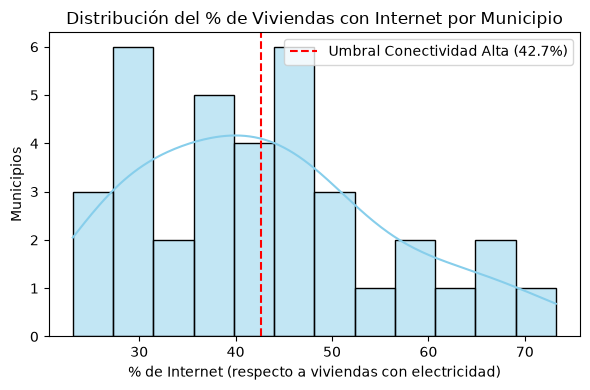

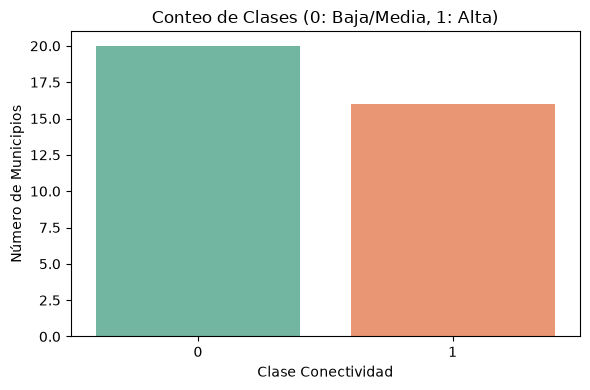

In [19]:
# Gráfico 1: Histograma de la distribución del porcentaje de viviendas con internet.
# CAMBIO: la linea de umbral usa la variable 'promedio_estatal_internet' calculada arriba
# (~42.7%), no un 30 fijo como en la version anterior.
plt.figure(figsize=(6, 4))
sns.histplot(
    df_limpio["pct_internet"], bins=12, kde=True, color="skyblue"
)
plt.axvline(
    promedio_estatal_internet,
    color="red",
    linestyle="--",
    label=f"Umbral Conectividad Alta ({promedio_estatal_internet:.1f}%)",
)
plt.title("Distribución del % de Viviendas con Internet por Municipio")
plt.xlabel("% de Internet (respecto a viviendas con electricidad)")
plt.ylabel("Municipios")
plt.legend()
plt.tight_layout()
plt.savefig("imagenes/grafica_1.png")
plt.show()

# Gráfico 2: Conteo de la variable objetivo binaria.
# CAMBIO: figura independiente en vez de compartir subplot(1,2,*) con la grafica 1;
# antes, al hacer plt.close() sobre la figura de dos paneles antes de dibujar este,
# matplotlib creaba una figura nueva con tamano por defecto y el titulo quedaba cortado.
plt.figure(figsize=(6, 4))
sns.countplot(
    x="conectividad_alta",
    data=df_limpio,
    palette="Set2",
    hue="conectividad_alta",
    legend=False,
)
plt.title("Conteo de Clases (0: Baja/Media, 1: Alta)")
plt.xlabel("Clase Conectividad")
plt.ylabel("Número de Municipios")
plt.tight_layout()
plt.savefig("imagenes/grafica_2.png")
plt.show()

In [20]:
# ------------------------------------------------------
# 7. MODELO APLICADO
# ------------------------------------------------------

In [21]:
# Dividir los datos en entrenamiento (70%) y prueba (30%) estratificando la variable objetivo.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Inicializar y entrenar el algoritmo DecisionTreeClassifier.
modelo = DecisionTreeClassifier(
    max_depth=4, random_state=42, criterion="gini"
)
modelo.fit(X_train, y_train)

print(f"\nModelo entrenado con éxito. Muestras en conjunto de entrenamiento: {X_train.shape[0]}")


Modelo entrenado con éxito. Muestras en conjunto de entrenamiento: 25


In [22]:
# ------------------------------------------------------
# 8. RESULTADOS
# ------------------------------------------------------

In [23]:
# Generar las predicciones con el conjunto de prueba.
y_pred = modelo.predict(X_test)

# Guardar outputs
test_results = X_test.copy()
test_results["conectividad_alta_real"] = y_test
test_results["prediccion_conectividad_alta"] = y_pred
test_results.to_csv("outputs/resultados_modelo.csv", index=False)

# Evaluar la exactitud y generar el reporte de métricas de clasificación.
acc = accuracy_score(y_test, y_pred)
print(f"\nExactitud (Accuracy) global del modelo: {acc:.4f}")
print("\nReporte detallado de clasificación:")
print(classification_report(y_test, y_pred))

# CAMBIO: se guarda el reporte de clasificacion a CSV para que outputs/resumen_resultados.csv
# quede sincronizado con el modelo vigente (antes correspondia a la version descartada).
reporte_dict = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(reporte_dict).transpose().to_csv("outputs/resumen_resultados.csv")


Exactitud (Accuracy) global del modelo: 0.9091

Reporte detallado de clasificación:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.80      0.89         5

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11



In [24]:
# ------------------------------------------------------
# 9. GRÁFICAS O TABLAS
# ------------------------------------------------------

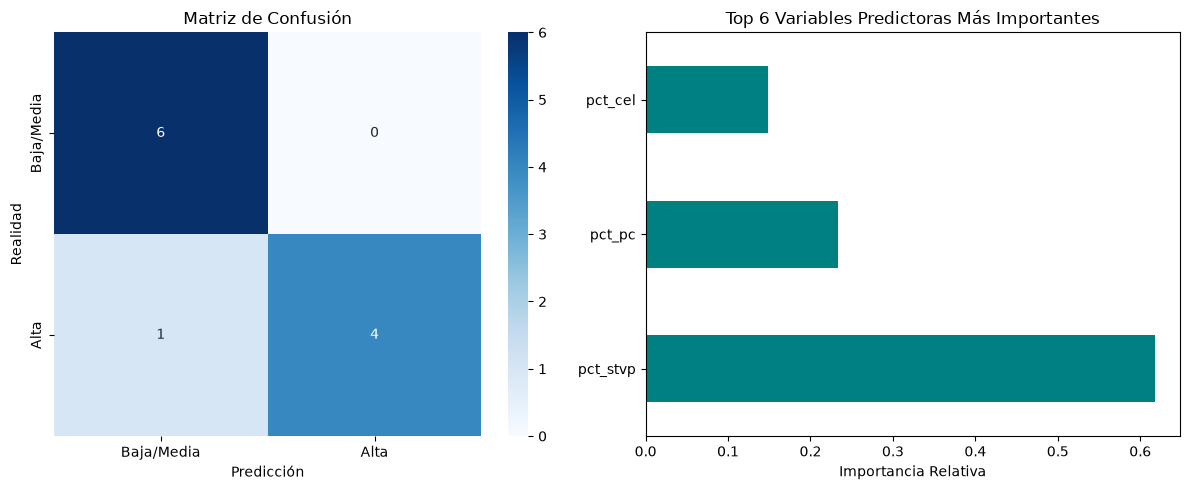

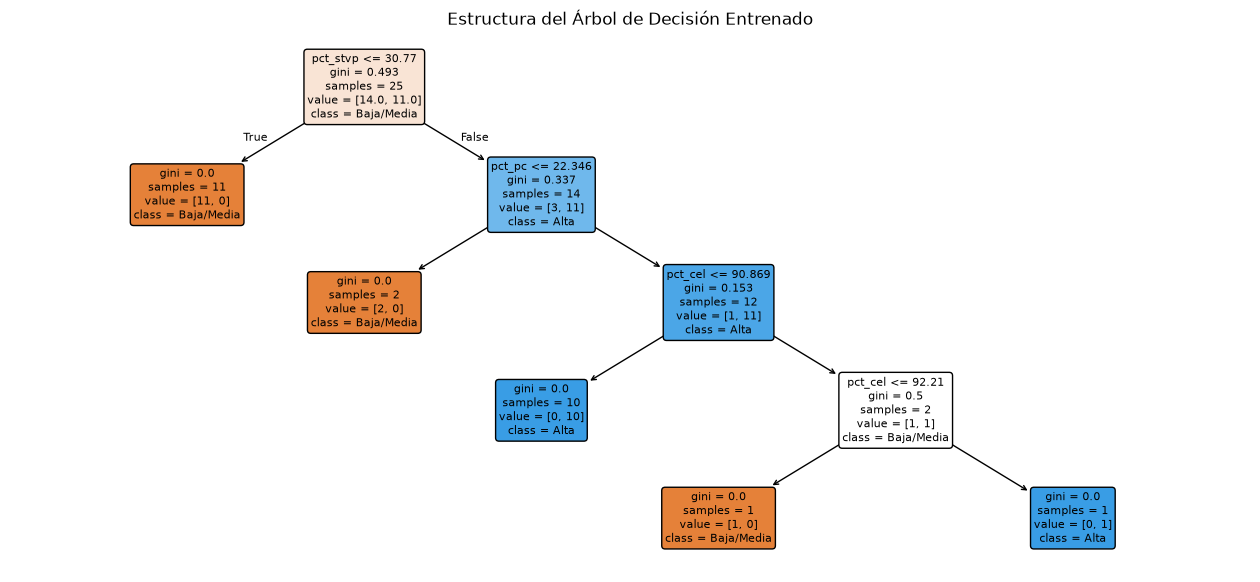

In [25]:
plt.figure(figsize=(12, 5))

# Matriz de confusión
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Baja/Media", "Alta"],
    yticklabels=["Baja/Media", "Alta"],
)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")

plt.ylabel("Realidad")

# Importancia de las variables predictoras (Top 6)
plt.subplot(1, 2, 2)
importancias = pd.Series(
    modelo.feature_importances_, index=X_encoded.columns
)
top_importancias = importancias.nlargest(6)
top_importancias.plot(kind="barh", color="teal")
plt.title("Top 6 Variables Predictoras Más Importantes")
plt.xlabel("Importancia Relativa")

plt.tight_layout()
plt.show()

# Representación visual de la estructura del Árbol de Decisión
plt.figure(figsize=(16, 7))
plot_tree(
    modelo,
    feature_names=X_encoded.columns,
    class_names=["Baja/Media", "Alta"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Estructura del Árbol de Decisión Entrenado")
plt.show()

In [26]:
# ------------------------------------------------------
# 10. INTERPRETACIÓN EN CELDAS MARKDOWN
# ------------------------------------------------------

### Conclusiones del Modelo de Clasificacion

1. **Rendimiento general:**
   * El modelo alcanzo una **exactitud de 0.91 (10 de 11 municipios de prueba)** en el conjunto de validacion. Con solo 36 municipios en total (25 de entrenamiento, 11 de prueba), esta cifra depende mucho de la particion aleatoria concreta; con una muestra tan chica no deberia leerse como una estimacion precisa del desempeno "real" del modelo, sino como una senal de que las variables elegidas son informativas.

2. **Variables clave:**
   * Segun `feature_importances_`, la variable con mayor peso fue **% de viviendas con TV de paga (`pct_stvp`)**, seguida de **% de viviendas con computadora/laptop (`pct_pc`)** y, en menor medida, **% de viviendas con celular (`pct_cel`)**.

3. **Aplicacion practica:**
   * El modelo permite identificar municipios con baja conectividad relativa para focalizar inversion en infraestructura de telecomunicaciones publica.

### Limitaciones

* **Umbral de la etiqueta:** se usa el promedio estatal de "% viviendas con internet" (relativo a viviendas con electricidad) como corte. No hay garantia de que ese corte coincida con lo que INEGI u otra fuente oficial consideraria "conectividad alta"; es una definicion propia de este analisis.
* **Variable de ocupantes por vivienda:** el promedio de ocupantes por vivienda es un indicador socioeconomico que podria enriquecer el modelo, pero no esta disponible en este tabulado del Censo 2020; se omitio en vez de aproximarla con datos que no estan en el dataset.
* **Tamano de la muestra:** al trabajar a nivel municipio (36 filas), el conjunto de prueba es de solo 11 municipios, por lo que las metricas de exactitud tienen bastante varianza y pueden cambiar de forma notoria si se usa otro `random_state`.
* **Confidencialidad de datos base:** el INEGI marca con "*" las cifras de localidades individuales con menos de tres viviendas. Ninguna de las 36 filas de nivel municipio usadas aqui trae valores marcados como confidenciales (el paso de imputacion "* -> 0" del codigo no llega a aplicarse en este analisis), pero no es posible verificar con este tabulado si los totales municipales que reporta el INEGI incorporan por completo el equipamiento de esas localidades pequenas.
* **Brecha digital multidimensional:** el modelo simplifica un fenomeno socioeconomico complejo a tres variables de equipamiento del hogar; no captura factores como cobertura de red, costo del servicio o alfabetizacion digital.